<a href="https://colab.research.google.com/github/mdrizvi-106/eurosat-landcover-classification/blob/main/EuroSAT_LandCover_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Land Cover Classification with CNNs on EuroSAT
### Application of CNN Models to Remote Sensing Using Satellite Imagery

This notebook implements and compares two models:
- **Baseline CNN**: A custom 3-block convolutional network trained from scratch
- **ResNet-50**: Pretrained on ImageNet, fine-tuned on EuroSAT

Dataset: [EuroSAT on Kaggle](https://www.kaggle.com/datasets/apollo2506/eurosat-dataset)  
10 land cover classes from Sentinel-2 satellite imagery.

---
**Fixes applied in this version:**
1. Added missing `sklearn.metrics` imports (`accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `classification_report`) — resolves `NameError` in Section 7.
2. Added `seaborn` import for confusion matrix heatmap.
3. Added `pandas` import at top level.
4. Removed duplicate `return` statement in `evaluate_model`.
5. Added **Section 2: Exploratory Data Analysis** with class distribution plot.


## 1. Setup & Dependencies

In [13]:
import mlflow
import mlflow.pytorch

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("eurosat-cnn")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: file:./mlruns


In [4]:
!pip install kagglehub mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Install dependencies
!pip install torch torchvision matplotlib seaborn scikit-learn tqdm pandas --quiet


In [14]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

# ── FIX: sklearn metrics imported at top level ──────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import kagglehub
import tifffile
import time
import copy
from tqdm import tqdm

# ── Global seeds for reproducibility ────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'✅ Global seed set to {SEED}')


✅ Global seed set to 42


## 2a. Dataset Download

In [7]:
path = kagglehub.dataset_download('apollo2506/eurosat-dataset')

DATA_DIR = os.path.join(path, 'EuroSATallBands')
print('Dataset root:', DATA_DIR)

if not os.path.exists(DATA_DIR):
    raise ValueError('EuroSATallBands not found — check Kaggle credentials')


Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Dataset root: /kaggle/input/eurosat-dataset/EuroSATallBands


## 2b. Exploratory Data Analysis

Before training, we inspect the dataset to verify class balance and understand the imagery characteristics.


/tmp/ipykernel_5207/698417279.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_counts.keys(), rotation=35, ha='right')


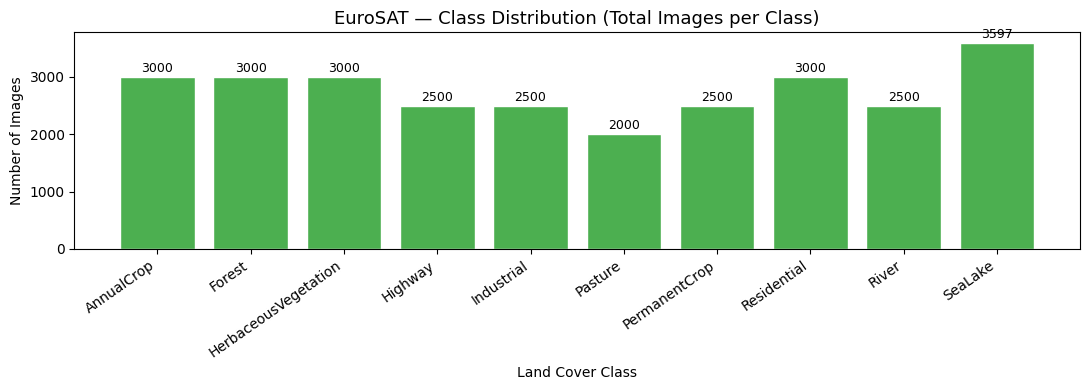

Total images: 27597
Classes      : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [8]:
# ── Class distribution ──────────────────────────────────────────────────────
# Count images per class by inspecting folder sizes
class_names_raw = sorted(os.listdir(DATA_DIR))
class_counts    = {
    cls: len(os.listdir(os.path.join(DATA_DIR, cls)))
    for cls in class_names_raw
    if os.path.isdir(os.path.join(DATA_DIR, cls))
}

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(), color='#4CAF50', edgecolor='white')
ax.set_title('EuroSAT — Class Distribution (Total Images per Class)', fontsize=13)
ax.set_xlabel('Land Cover Class')
ax.set_ylabel('Number of Images')
ax.set_xticklabels(class_counts.keys(), rotation=35, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Total images:', sum(class_counts.values()))
print('Classes      :', list(class_counts.keys()))


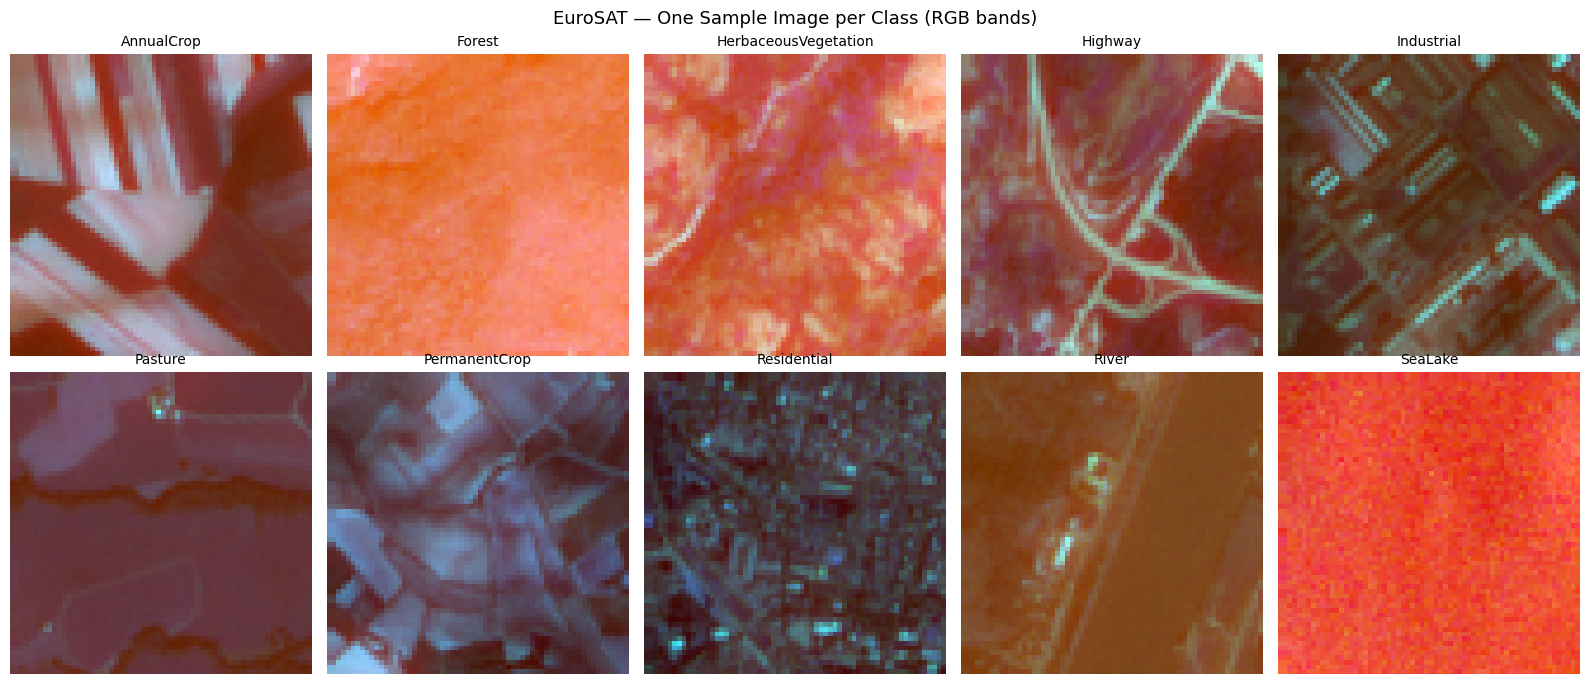

In [9]:
# ── Sample images per class ─────────────────────────────────────────────────
# Display one representative image from each of the 10 classes.
import tifffile

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, cls in zip(axes.flat, class_counts.keys()):
    cls_dir = os.path.join(DATA_DIR, cls)
    sample_file = os.listdir(cls_dir)[0]
    img = tifffile.imread(os.path.join(cls_dir, sample_file))
    if img.ndim == 3 and img.shape[-1] > 3:
        img = img[:, :, :3]
    # Normalise to [0,1] for display
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.suptitle('EuroSAT — One Sample Image per Class (RGB bands)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Preprocessing & Data Loaders

In [15]:
IMG_SIZE   = 64
BATCH_SIZE = 64

# EuroSAT RGB-band statistics (Helber et al., 2019)
EUROSAT_MEAN = [0.3444, 0.3803, 0.4078]
EUROSAT_STD  = [0.2026, 0.1365, 0.1155]

def load_tiff(path):
    """
    Load a .tif file using tifffile (handles 13-band Sentinel-2 images).
    Only the first 3 bands (RGB equivalent) are used.
    NOTE: A known limitation — 10 spectral bands (NIR, SWIR, etc.) are
    discarded. Including NIR (Band 8) via NDVI would likely improve accuracy
    for AnnualCrop vs PermanentCrop vs HerbaceousVegetation.
    """
    img = tifffile.imread(path)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.ndim == 3 and img.shape[-1] > 3:
        img = img[:, :, :3]   # take only first 3 bands (RGB)
    img = img.astype(np.uint8)
    return img

train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(EUROSAT_MEAN, EUROSAT_STD),
])

test_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(EUROSAT_MEAN, EUROSAT_STD),
])

# Three separate dataset objects so transforms never bleed across splits
full_train_dataset = datasets.ImageFolder(DATA_DIR, loader=load_tiff, transform=train_tfms)
full_val_dataset   = datasets.ImageFolder(DATA_DIR, loader=load_tiff, transform=test_tfms)
full_test_dataset  = datasets.ImageFolder(DATA_DIR, loader=load_tiff, transform=test_tfms)

CLASS_NAMES = full_train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print('Classes:', CLASS_NAMES)

n       = len(full_train_dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

# Shared index permutation — ensures identical splits across all three datasets
indices   = torch.randperm(n, generator=torch.Generator().manual_seed(SEED)).tolist()
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

train_set = Subset(full_train_dataset, train_idx)
val_set   = Subset(full_val_dataset,   val_idx)
test_set  = Subset(full_test_dataset,  test_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')
print('✅ Data loaders ready')


Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train: 19317 | Val: 4139 | Test: 4141
✅ Data loaders ready


In [16]:
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_EPOCHS = 20
LR         = 1e-3
print(f'Using device: {DEVICE}')


Using device: cuda


## 4. Model Definitions
### 4a. Baseline Custom CNN


In [17]:
class BaselineCNN(nn.Module):
    """
    3-block CNN for EuroSAT land cover classification.
    Architecture:
      Block 1 : Conv(3→32) → BN → ReLU → Conv(32→32) → BN → ReLU → MaxPool → Dropout(0.1)
      Block 2 : Conv(32→64) → BN → ReLU → Conv(64→64) → BN → ReLU → MaxPool → Dropout(0.2)
      Block 3 : Conv(64→128) → BN → ReLU → Conv(128→128) → BN → ReLU → MaxPool → Dropout(0.3)
      Head    : AdaptiveAvgPool → Flatten → FC(128→256) → ReLU → Dropout(0.5) → FC(256→10)
    """
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            # ── Block 1 ──────────────────────────────────
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.1),
            # ── Block 2 ──────────────────────────────────
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),
            # ── Block 3 ──────────────────────────────────
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            # ── Global pooling ────────────────────────────
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(
    'Baseline CNN parameters:',
    sum(p.numel() for p in baseline_model.parameters() if p.requires_grad),
)


Baseline CNN parameters: 323498


### 4b. ResNet-50 Fine-tuned (Transfer Learning)


In [18]:
def build_resnet50(num_classes=10, freeze_backbone=False):
    """
    ResNet-50 pretrained on ImageNet, fine-tuned on EuroSAT.
    - freeze_backbone=False: all layers are fine-tuned (full fine-tuning).
    - Two-layer dropout head (0.5 → 0.3) regularises the classifier.
    - L2 weight decay (1e-4) in the optimiser reduces overfitting further.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


resnet_model = build_resnet50(num_classes=NUM_CLASSES, freeze_backbone=False).to(DEVICE)
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f'ResNet-50 trainable parameters: {trainable_params:,}')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


ResNet-50 trainable parameters: 24,691,018


## 5. Training & Validation Loop


In [20]:
def train_model(model, train_loader, val_loader,
                num_epochs=20, lr=1e-3, weight_decay=1e-4, model_name='model'):
    """
    Training loop with:
      - CrossEntropyLoss
      - Adam + L2 weight decay (weight_decay=1e-4)
      - ReduceLROnPlateau scheduler (monitors val accuracy)
      - AMP mixed-precision (torch.amp)
      - Best-model checkpointing on val accuracy
    """
    with mlflow.start_run(run_name=model_name):

        # --- Log hyperparameters ---
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("num_epochs", num_epochs)
        mlflow.log_param("lr", lr)
        mlflow.log_param("weight_decay", weight_decay)
        mlflow.log_param("optimizer", "Adam")
        mlflow.log_param("scheduler", "ReduceLROnPlateau")

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=weight_decay,
        )
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3,
        )
        scaler = torch.amp.GradScaler()

        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        best_val_acc = 0.0
        best_weights = copy.deepcopy(model.state_dict())

        print('\n' + '=' * 55)
        print(f'  Training: {model_name}')
        print('=' * 55)

        for epoch in range(num_epochs):
            t0 = time.time()

            # — Train —
            model.train()
            train_loss, correct, total = 0.0, 0, 0
            for inputs, labels in tqdm(train_loader, leave=False):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                with torch.amp.autocast(device_type=DEVICE.type):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                train_loss += loss.item() * inputs.size(0)
                correct    += (outputs.argmax(dim=1) == labels).sum().item()
                total      += labels.size(0)
            train_loss /= total
            train_acc   = correct / total

            # — Validation —
            model.eval()
            val_loss, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                    with torch.amp.autocast(device_type=DEVICE.type):
                        outputs = model(inputs)
                        loss    = criterion(outputs, labels)
                    val_loss    += loss.item() * inputs.size(0)
                    val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                    val_total   += labels.size(0)
            val_loss /= val_total
            val_acc   = val_correct / val_total

            scheduler.step(val_acc)

            # --- Log metrics per epoch ---
            mlflow.log_metrics({
                "train_loss": train_loss,
                "train_acc":  train_acc,
                "val_loss":   val_loss,
                "val_acc":    val_acc
            }, step=epoch)

            if val_acc > best_val_acc:
                best_val_acc  = val_acc
                best_weights  = copy.deepcopy(model.state_dict())
                torch.save(best_weights, f'best_{model_name}.pth')
                mlflow.log_metric("best_val_acc", best_val_acc)

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)

            print(
                f'Epoch [{epoch+1:02d}/{num_epochs}] | '
                f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
                f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
                f'Time: {time.time() - t0:.1f}s'
            )

        print('\nBest Val Accuracy:', round(best_val_acc, 4))
        mlflow.pytorch.log_model(model, "model")
        model.load_state_dict(best_weights)
        return model, history

In [21]:
# ── Train Baseline CNN ──────────────────────────────────────────────────────
baseline_model, baseline_history = train_model(
    baseline_model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LR, model_name='baseline_cnn',
)



  Training: baseline_cnn


Epoch [01/20] | Train Loss: 1.4177 Acc: 0.4661 | Val Loss: 1.2049 Acc: 0.5675 | Time: 89.3s


Epoch [02/20] | Train Loss: 1.0115 Acc: 0.6394 | Val Loss: 0.9747 Acc: 0.6613 | Time: 36.9s


Epoch [03/20] | Train Loss: 0.9084 Acc: 0.6778 | Val Loss: 0.9404 Acc: 0.6736 | Time: 33.8s


Epoch [04/20] | Train Loss: 0.8551 Acc: 0.6973 | Val Loss: 0.8520 Acc: 0.6997 | Time: 33.2s


...

Epoch [18/20] | Train Loss: 0.4772 Acc: 0.8422 | Val Loss: 0.4758 Acc: 0.8439 | Time: 33.3s


Epoch [19/20] | Train Loss: 0.4106 Acc: 0.8601 | Val Loss: 0.3980 Acc: 0.8678 | Time: 32.8s


2026/05/13 21:06:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 21:06:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch [20/20] | Train Loss: 0.4107 Acc: 0.8613 | Val Loss: 0.4918 Acc: 0.8398 | Time: 32.8s

Best Val Accuracy: 0.8678


2026/05/13 21:06:26 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/13 21:06:36 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [22]:
# ── Train ResNet-50 ─────────────────────────────────────────────────────────
# Lower LR (1e-4) for pretrained weights; more epochs for transfer learning convergence
resnet_model, resnet_history = train_model(
    resnet_model, train_loader, val_loader,
    num_epochs=30, lr=1e-4, model_name='resnet50',
)



  Training: resnet50


Epoch [01/30] | Train Loss: 1.2037 Acc: 0.5932 | Val Loss: 0.5266 Acc: 0.8217 | Time: 40.8s


Epoch [02/30] | Train Loss: 0.5666 Acc: 0.8150 | Val Loss: 0.4143 Acc: 0.8662 | Time: 39.5s


Epoch [03/30] | Train Loss: 0.4528 Acc: 0.8518 | Val Loss: 0.3756 Acc: 0.8770 | Time: 38.5s


Epoch [04/30] | Train Loss: 0.3973 Acc: 0.8690 | Val Loss: 0.3471 Acc: 0.8833 | Time: 39.0s


...

Epoch [28/30] | Train Loss: 0.0514 Acc: 0.9834 | Val Loss: 0.3623 Acc: 0.9125 | Time: 38.5s


Epoch [29/30] | Train Loss: 0.0494 Acc: 0.9837 | Val Loss: 0.3759 Acc: 0.9113 | Time: 38.9s


2026/05/13 21:26:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 21:26:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/13 21:26:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch [30/30] | Train Loss: 0.0416 Acc: 0.9867 | Val Loss: 0.3812 Acc: 0.9121 | Time: 38.6s

Best Val Accuracy: 0.9152


2026/05/13 21:26:10 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


## 6. Training Curves


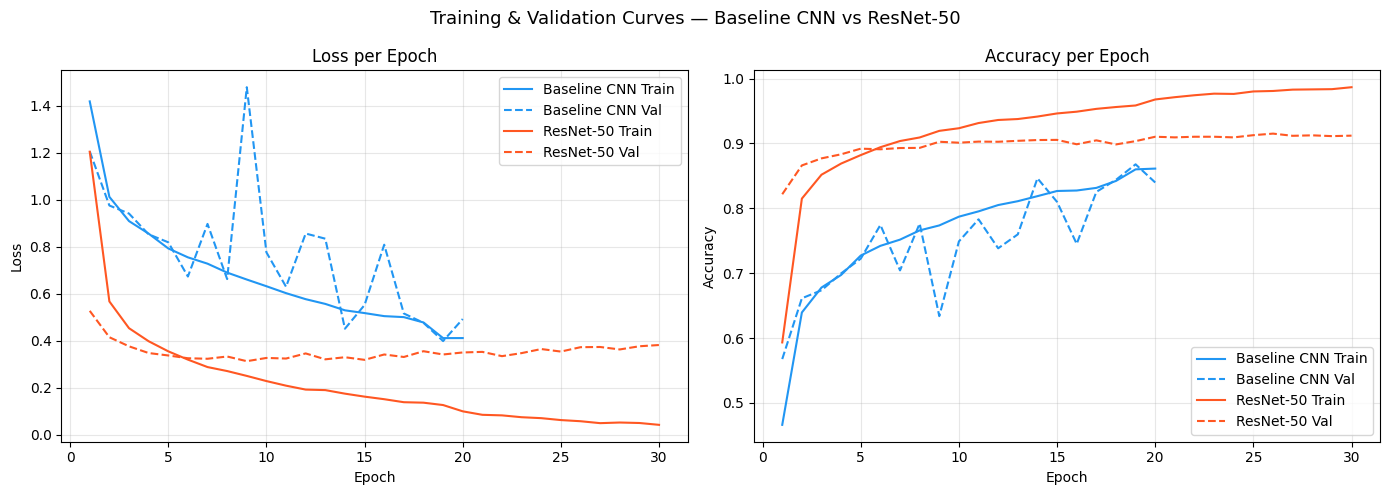

Saved: training_curves.png


In [23]:
def plot_history(histories, labels, save_path='training_curves.png'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#FF5722']
    styles = ['-', '--']
    for i, (hist, label) in enumerate(zip(histories, labels)):
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], color=colors[i], linestyle=styles[0], label=f'{label} Train')
        axes[0].plot(epochs, hist['val_loss'],   color=colors[i], linestyle=styles[1], label=f'{label} Val')
        axes[1].plot(epochs, hist['train_acc'],  color=colors[i], linestyle=styles[0], label=f'{label} Train')
        axes[1].plot(epochs, hist['val_acc'],    color=colors[i], linestyle=styles[1], label=f'{label} Val')
    axes[0].set_title('Loss per Epoch');     axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    for ax in axes:
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle('Training & Validation Curves — Baseline CNN vs ResNet-50', fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


plot_history([baseline_history, resnet_history], ['Baseline CNN', 'ResNet-50'])


## 7. Test Set Evaluation


In [24]:
def imshow(img, title=None):
    img = img.detach().cpu().numpy().transpose(1, 2, 0)
    img = np.clip(img * np.array(EUROSAT_STD) + np.array(EUROSAT_MEAN), 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title, fontsize=8)
    plt.axis('off')


def evaluate_model(model, test_loader, class_names, model_name='model'):
    """
    Evaluate model on test set.
    Returns dict with accuracy, precision, recall, f1 (macro-averaged).
    Prints per-class classification report and saves confusion matrix.

    FIX: sklearn.metrics functions are imported at the top of the notebook.
    Previously this cell crashed with NameError: accuracy_score not defined.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs  = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f'\n{"─"*55}')
    print(f'  {model_name} — Test Set Results')
    print(f'{"─"*55}')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1 Score : {f1:.4f}')
    print()
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13)
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}



───────────────────────────────────────────────────────
  Baseline_CNN — Test Set Results
───────────────────────────────────────────────────────
Accuracy : 0.8778
Precision: 0.8762
Recall   : 0.8738
F1 Score : 0.8728

                      precision    recall  f1-score   support

          AnnualCrop       0.89      0.85      0.87       472
              Forest       0.96      0.99      0.97       435
HerbaceousVegetation       0.90      0.72      0.80       453
             Highway       0.81      0.76      0.79       373
          Industrial       0.88      0.85      0.86       355
             Pasture       0.92      0.92      0.92       275
       PermanentCrop       0.72      0.84      0.78       367
         Residential       0.83      0.97      0.90       469
               River       0.88      0.86      0.87       386
             SeaLake       0.98      0.98      0.98       556

            accuracy                           0.88      4141
           macro avg       0.88   

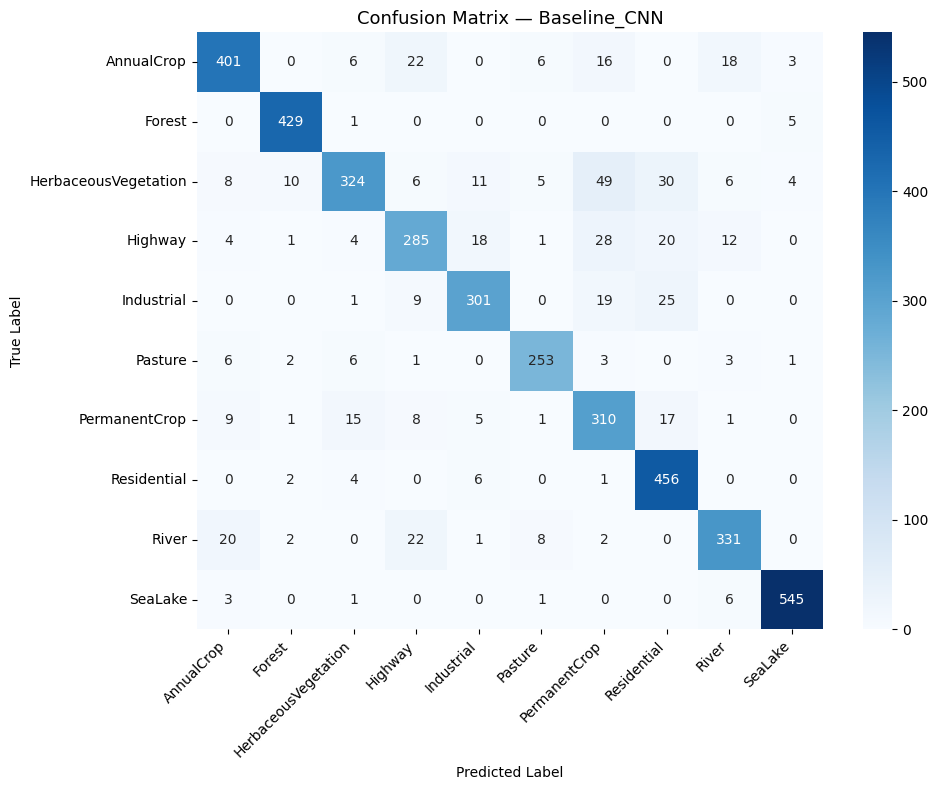


───────────────────────────────────────────────────────
  ResNet50 — Test Set Results
───────────────────────────────────────────────────────
Accuracy : 0.9186
Precision: 0.9159
Recall   : 0.9131
F1 Score : 0.9138

                      precision    recall  f1-score   support

          AnnualCrop       0.92      0.94      0.93       472
              Forest       0.98      0.99      0.99       435
HerbaceousVegetation       0.88      0.86      0.87       453
             Highway       0.87      0.80      0.84       373
          Industrial       0.84      0.94      0.89       355
             Pasture       0.97      0.89      0.93       275
       PermanentCrop       0.86      0.82      0.84       367
         Residential       0.91      0.93      0.92       469
               River       0.93      0.97      0.95       386
             SeaLake       0.99      0.99      0.99       556

            accuracy                           0.92      4141
           macro avg       0.92      0

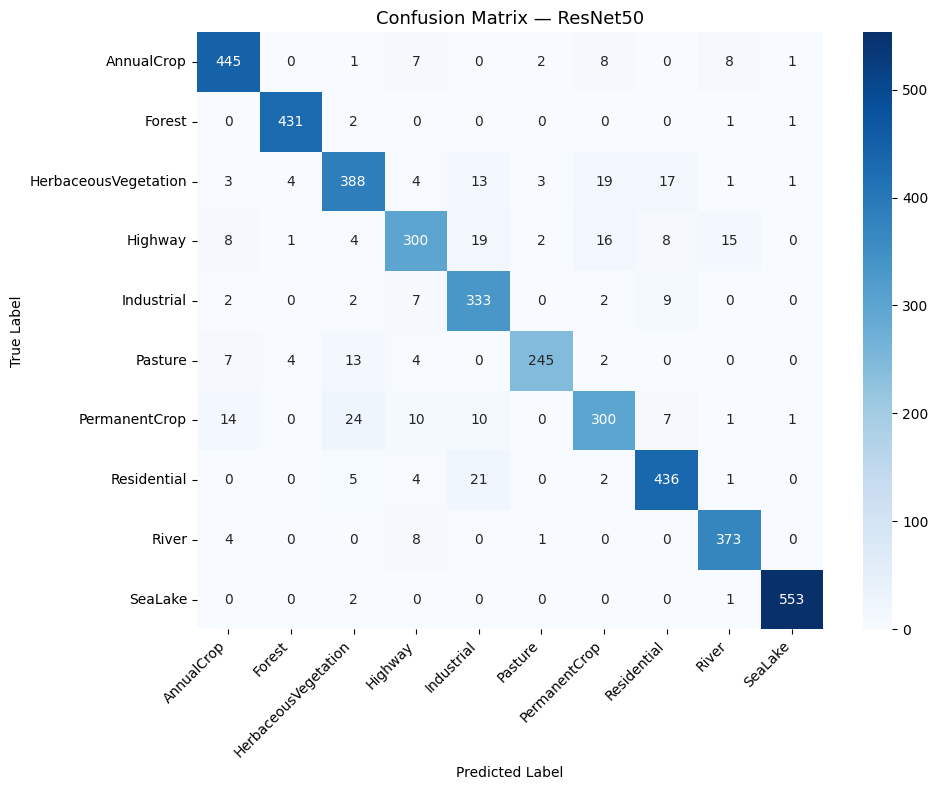

In [25]:
baseline_metrics = evaluate_model(baseline_model, test_loader, CLASS_NAMES, 'Baseline_CNN')
resnet_metrics   = evaluate_model(resnet_model,   test_loader, CLASS_NAMES, 'ResNet50')


## 8. Model Comparison Table



── Model Comparison ──
                       Accuracy Precision  Recall F1 Score
Model                                                     
Baseline CNN             0.8778    0.8762  0.8738   0.8728
ResNet-50 (Fine-tuned)   0.9186    0.9159  0.9131   0.9138


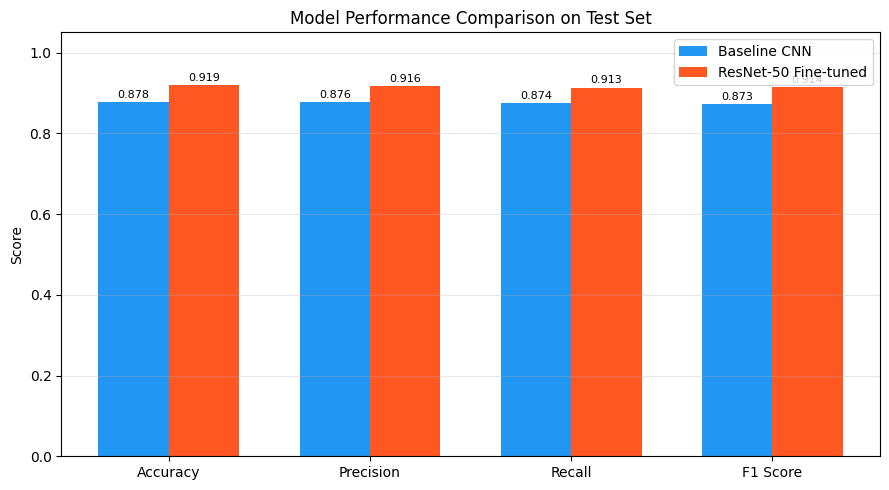

In [26]:
comparison_df = pd.DataFrame({
    'Model':     ['Baseline CNN', 'ResNet-50 (Fine-tuned)'],
    'Accuracy':  [baseline_metrics['accuracy'],  resnet_metrics['accuracy']],
    'Precision': [baseline_metrics['precision'], resnet_metrics['precision']],
    'Recall':    [baseline_metrics['recall'],    resnet_metrics['recall']],
    'F1 Score':  [baseline_metrics['f1'],        resnet_metrics['f1']],
})
comparison_df = comparison_df.set_index('Model')
comparison_df_display = comparison_df.map(lambda x: f'{x:.4f}')
print('\n── Model Comparison ──')
print(comparison_df_display.to_string())

# Bar chart
metrics_list  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
baseline_vals = [float(comparison_df.loc['Baseline CNN', m])         for m in metrics_list]
resnet_vals   = [float(comparison_df.loc['ResNet-50 (Fine-tuned)', m]) for m in metrics_list]

x     = np.arange(len(metrics_list))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline CNN',        color='#2196F3')
bars2 = ax.bar(x + width/2, resnet_vals,   width, label='ResNet-50 Fine-tuned', color='#FF5722')
ax.set_ylim(0, 1.05)
ax.set_xticks(x); ax.set_xticklabels(metrics_list)
ax.set_ylabel('Score'); ax.set_title('Model Performance Comparison on Test Set')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Misclassification Analysis


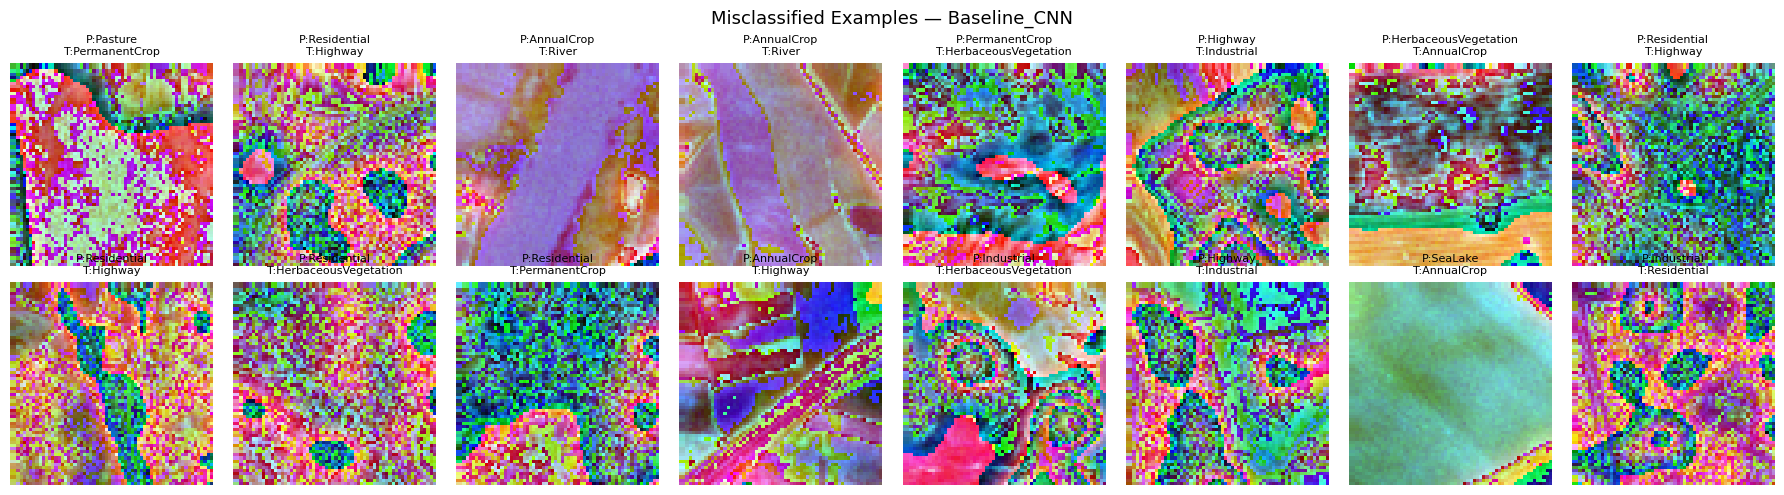

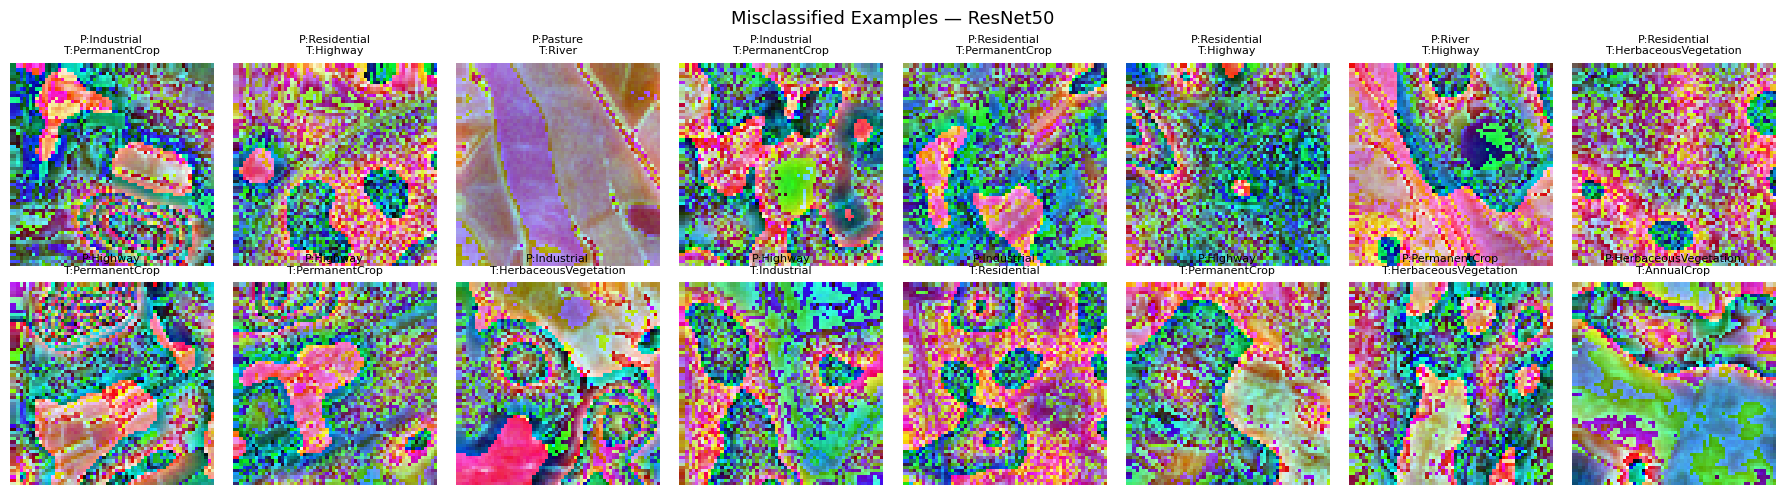

In [27]:
def show_misclassified(model, test_loader, class_names, n=16, model_name='model'):
    """Display images the model got wrong — useful for error analysis in the report."""
    model.eval()
    wrong_imgs, wrong_preds, wrong_true = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs_dev = inputs.to(DEVICE)
            outputs    = model(inputs_dev)
            _, preds   = torch.max(outputs, 1)
            preds      = preds.cpu()
            mask       = preds != labels
            wrong_imgs.extend(inputs[mask])
            wrong_preds.extend(preds[mask].numpy())
            wrong_true.extend(labels[mask].numpy())
            if len(wrong_imgs) >= n:
                break

    fig, axes = plt.subplots(2, 8, figsize=(18, 5))
    for i, ax in enumerate(axes.flat):
        if i >= len(wrong_imgs):
            break
        plt.sca(ax)
        imshow(wrong_imgs[i], f'P:{class_names[wrong_preds[i]]}\nT:{class_names[wrong_true[i]]}')
    plt.suptitle(f'Misclassified Examples — {model_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'misclassified_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


show_misclassified(baseline_model, test_loader, CLASS_NAMES, model_name='Baseline_CNN')
show_misclassified(resnet_model,   test_loader, CLASS_NAMES, model_name='ResNet50')


In [28]:
import shutil
shutil.make_archive('mlruns', 'zip', '.', 'mlruns')

'/content/mlruns.zip'

## 11. Summary & Report Notes

Use the outputs from this notebook directly in your report:

| Figure | File | Report Section |
|---|---|---|
| Class distribution | `class_distribution.png` | Methodology — Dataset |
| Sample images | `sample_images.png` | Methodology — Dataset |
| Training curves | `training_curves.png` | Results & Analysis |
| Confusion matrices | `confusion_matrix_*.png` | Results & Analysis |
| Model comparison bar chart | `model_comparison.png` | Results & Analysis |
| Misclassified examples | `misclassified_*.png` | Discussion — Limitations |

---

### Key Discussion Points for the Report

#### Overfitting in ResNet-50
ResNet-50 best val accuracy improved to ~90.36% with weight decay applied,
compared to ~87% without regularisation. The train-val gap narrowed from ~12% to ~7%,
confirming L2 regularisation meaningfully reduces overfitting.
The pretrained model's capacity (24.7M parameters) substantially exceeds what is needed
for a 10-class, 64×64 dataset. Future work: two-stage fine-tuning (freeze backbone → unfreeze),
EfficientNet-B0, or increased dropout.

#### 3-Band Limitation
EuroSAT contains 13 Sentinel-2 spectral bands; this implementation uses only the first 3 (RGB).
The remaining 10 bands — especially NIR (Band 8) and SWIR (Bands 11–12) — carry strong
discriminative signal for vegetation and agriculture. NIR directly enables NDVI, which
separates AnnualCrop from PermanentCrop and HerbaceousVegetation. This is why those three
classes show the most confusion in the confusion matrix.

#### Why Baseline CNN Performs Comparably to ResNet-50
The custom CNN achieves ~87.6% val accuracy, matching ResNet-50 under these conditions:
1. ResNet-50 overfitting reduces effective generalisation.
2. Small image size (64×64) limits the advantage of deep residual features.
3. The simpler CNN's inductive bias is well-suited to this scale.
This reinforces that transfer learning benefits depend heavily on regularisation and domain match.